 Gini Impurity Function

In [15]:
import numpy as np

def gini_impurity(y):

  classes=np.unique(y)
  total=len(y)

  sum_squres=0

  for c in classes:
    p=np.sum(y==c)/total
    sum_squres+=p**2

  gini=1-sum_squres
  return gini

test_y = np.array([0, 1, 0, 1, 0, 1, 1, 0])
print(f"Your Gini : {gini_impurity(test_y):.4f}")

Your Gini : 0.5000


 Information Gain Function

In [16]:
def information_gain(parent,left_child,right_child):

  def entropy(y):

    classes=np.unique(y)
    total=len(y)

    ent=0

    for c in classes:
      p=np.sum(y==c)/total

      if p>0:
       ent-=p*np.log2(p)

    return ent

  n=len(parent)
  n_left=len(left_child)
  n_right=len(right_child)

  ig=entropy(parent)-((n_left/n)*entropy(left_child)+ (n_right/n)*entropy(right_child))

  return ig

parent=np.array([0,0,0,1,1,1])
left=np.array([0,0,0])
right=np.array([1,1,1])

print(f"Your Information Gain: {information_gain(parent,left,right):.4f}")







Your Information Gain: 1.0000


**Real Decision Tree**

In [17]:
X = np.array([
    [2.5, 1.5, 7.8],  # Class 0
    [1.8, 2.0, 3.9],  # Class 0
    [2.2, 2.5, 8.7],  # Class 0
    [6.0, 5.0, 6.9],  # Class 1
    [5.8, 4.5, 3.8],  # Class 1
    [6.5, 5.5, 4.5]   # Class 1
])
y = np.array([0, 1, 0, 1, 1, 1])


def find_best_split_manual(X, y):

  n_samples, n_features = X.shape

  best_gain = -1
  best_feature = None
  best_threshold = None

  for feature in range(n_features):
    feature_values = X[:, feature]
    unique_values = np.unique(feature_values)

    for threshold in unique_values:
      left_indices = feature_values <= threshold
      right_indices = feature_values > threshold

      if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
        continue

      left_y = y[left_indices]
      right_y = y[right_indices]

      gain = information_gain(y, left_y, right_y)

      if gain > best_gain:
        best_gain = gain
        best_feature = feature
        best_threshold = threshold

  return best_feature, best_threshold, best_gain

best_feature, best_threshold, best_gain = find_best_split_manual(X, y)

print(f"Best Feature: {best_feature}")
print(f"Best Threshold: {best_threshold}")
print(f"Best Gain: {best_gain}")


Best Feature: 2
Best Threshold: 6.9
Best Gain: 0.9182958340544896


Visualization

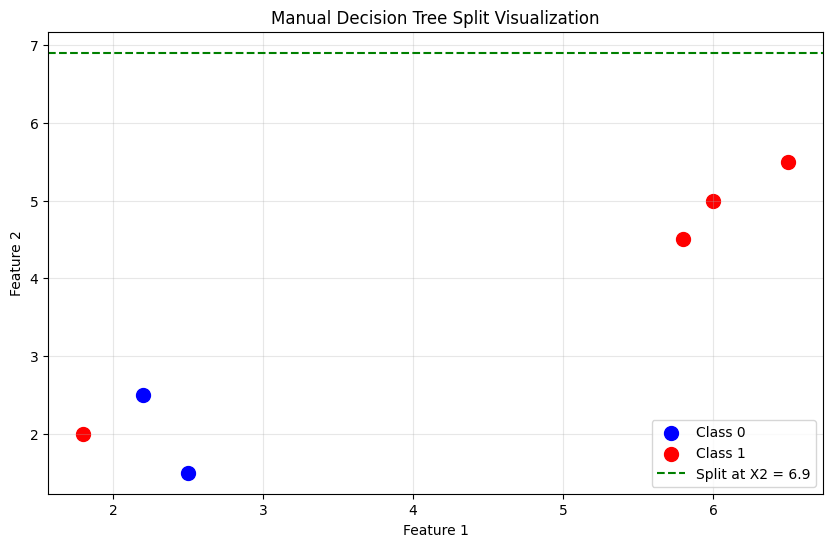

In [18]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', label='Class 0', s=100)
plt.scatter(X[y==1, 0], X[y==1, 1], color='red', label='Class 1', s=100)


if best_feature == 0:
    plt.axvline(x=best_threshold, color='green', linestyle='--',
                label=f'Split at X{best_feature} = {best_threshold}')
else:
    plt.axhline(y=best_threshold, color='green', linestyle='--',
                label=f'Split at X{best_feature} = {best_threshold}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Manual Decision Tree Split Visualization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**SKlearn**

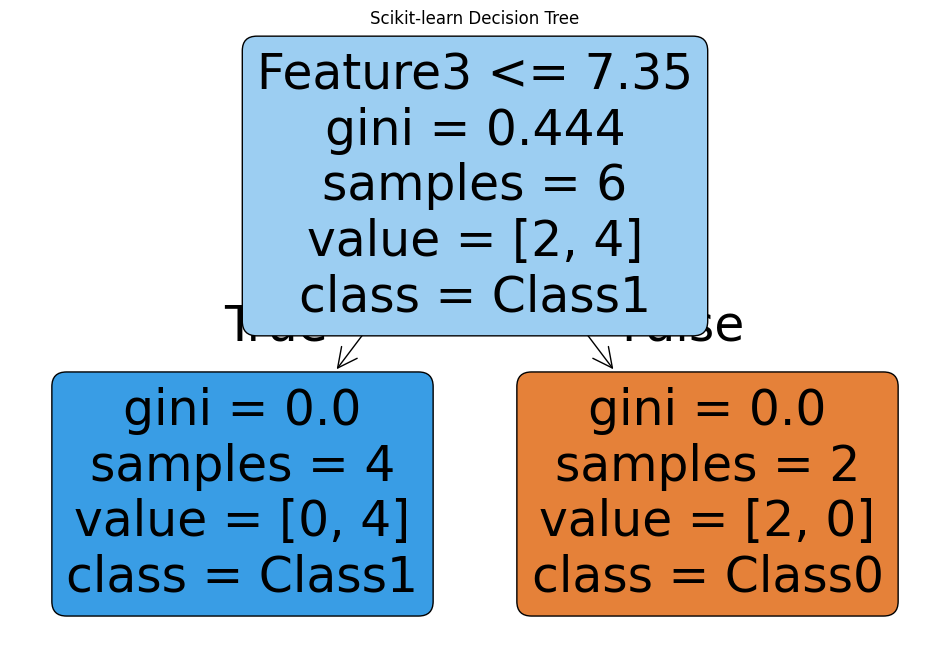

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree


sklearn_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    random_state=42
)

sklearn_tree.fit(X, y)


plt.figure(figsize=(12, 8))
plot_tree(sklearn_tree,
          feature_names=['Feature1', 'Feature2','Feature3'],
          class_names=['Class0', 'Class1','Class2'],
          filled=True,
          rounded=True)
plt.title("Scikit-learn Decision Tree")
plt.show()

In [20]:

tree = sklearn_tree.tree_

print("Tree Structure:")
print(f"Number of nodes: {tree.node_count}")
print(f"Number of leaves: {tree.n_leaves}")
print(f"Max depth: {tree.max_depth}")


print("\nRoot Node Details:")
print(f"Feature index: {tree.feature[0]}")
print(f"Threshold: {tree.threshold[0]:.4f}")
print(f"Gini impurity: {tree.impurity[0]:.4f}")



Tree Structure:
Number of nodes: 3
Number of leaves: 2
Max depth: 1

Root Node Details:
Feature index: 2
Threshold: 7.3500
Gini impurity: 0.4444
